In [15]:
# ============================================================
# 셀 1 - 라이브러리 임포트 및 경로 설정
# 학습된 모델과 threshold를 불러와서
# 새로운 이미지/영상에 대해 real/fake를 판별합니다.
# ============================================================

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import json
import cv2
from pathlib import Path
from torchvision import transforms
from transformers import ViTModel
from PIL import Image

BASE_DIR  = Path(r"C:\Users\user\Desktop\deepfake-detector")
MODEL_DIR = BASE_DIR / "models" / "occ"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [16]:
# ============================================================
# 셀 2 - 모델 구조 정의 및 best_model.pth 로드
# 12_train_occ.ipynb와 동일한 구조입니다.
# ============================================================

class ViTAutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = ViTModel.from_pretrained("google/vit-base-patch16-224-in21k")
        self.encoder_dim = 768
        self.decoder = nn.Sequential(
            nn.Linear(self.encoder_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 768),
            nn.Tanh()
        )

    def forward(self, x):
        outputs = self.vit(pixel_values=x)
        patch_embeddings = outputs.last_hidden_state[:, 1:, :]
        reconstructed_patches = self.decoder(patch_embeddings)
        B = x.shape[0]
        patches = reconstructed_patches.view(B, 14, 14, 16, 16, 3)
        patches = patches.permute(0, 5, 1, 3, 2, 4)
        image = patches.contiguous().view(B, 3, 224, 224)
        return image

model = ViTAutoEncoder()
model.load_state_dict(torch.load(MODEL_DIR / "best_model.pth", map_location=DEVICE))
model = model.to(DEVICE)
model.eval()
print("모델 로드 완료")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

모델 로드 완료


In [17]:
# ============================================================
# 셀 3 - threshold.json 로드
# 13_threshold.ipynb에서 저장한 threshold 값을 불러옵니다.
# 기본은 2std 사용, 필요시 3std로 변경 가능합니다.
# ============================================================

with open(MODEL_DIR / "threshold.json") as f:
    threshold_data = json.load(f)

THRESHOLD = threshold_data["threshold_2std"]  # 필요시 threshold_3std로 변경

print(f"mean:      {threshold_data['mean']:.6f}")
print(f"std:       {threshold_data['std']:.6f}")
print(f"threshold: {THRESHOLD:.6f} (2std)")

mean:      0.000435
std:       0.000431
threshold: 0.001297 (2std)


In [18]:
# ============================================================
# 셀 4 - 전처리 및 inference 함수 정의
# predict_image: 이미지 한 장 판별
# predict_video: 영상에서 프레임 샘플링 후 판별
#   - 프레임별 error를 계산하고 평균으로 최종 판별
#   - 결과 시각화까지 포함
# ============================================================

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

criterion = nn.MSELoss(reduction="none")


def predict_image(image_path):
    """이미지 한 장을 받아 real/fake 판별"""
    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(DEVICE)  # (1, 3, 224, 224)

    with torch.no_grad():
        reconstructed = model(tensor)
        error = criterion(reconstructed, tensor).mean().item()

    result = "FAKE" if error > THRESHOLD else "REAL"
    confidence = min(abs(error - THRESHOLD) / THRESHOLD * 100, 100)

    print(f"경로: {image_path}")
    print(f"reconstruction error: {error:.6f}")
    print(f"threshold:            {THRESHOLD:.6f}")
    print(f"판별 결과: {result} (차이: {confidence:.1f}%)")
    return {"result": result, "error": error, "confidence": confidence}


def predict_video(video_path, sample_frames=32, visualize=True):
    """영상에서 프레임을 샘플링해서 real/fake 판별"""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        print(f"영상을 열 수 없습니다: {video_path}")
        return None

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = cap.get(cv2.CAP_PROP_FPS)
    duration = total_frames / fps if fps > 0 else 0

    # 균등 간격으로 프레임 샘플링
    indices = np.linspace(0, total_frames - 1, sample_frames, dtype=int)
    frames, errors = [], []

    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        img = Image.fromarray(frame_rgb)
        tensor = transform(img).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            reconstructed = model(tensor)
            error = criterion(reconstructed, tensor).mean().item()

        frames.append(frame_rgb)
        errors.append(error)

    cap.release()

    errors = np.array(errors)
    mean_error = errors.mean()
    fake_frame_ratio = (errors > THRESHOLD).mean() * 100
    result = "FAKE" if mean_error > THRESHOLD else "REAL"

    print(f"\n경로: {video_path}")
    print(f"총 프레임: {total_frames} | FPS: {fps:.1f} | 길이: {duration:.1f}초")
    print(f"샘플 프레임: {len(errors)}장")
    print(f"평균 error:  {mean_error:.6f}")
    print(f"threshold:   {THRESHOLD:.6f}")
    print(f"FAKE 판정 프레임 비율: {fake_frame_ratio:.1f}%")
    print(f"최종 판별: {result}")

    if visualize:
        _visualize_video_result(frames, errors, result, mean_error, video_path)

    return {
        "result": result,
        "mean_error": mean_error,
        "errors": errors.tolist(),
        "fake_frame_ratio": fake_frame_ratio,
    }


def _visualize_video_result(frames, errors, result, mean_error, video_path):
    """프레임별 error 시각화"""
    n = min(8, len(frames))  # 최대 8프레임 시각화
    fig, axes = plt.subplots(2, n, figsize=(n * 2.5, 6))

    color = "red" if result == "FAKE" else "green"

    for i in range(n):
        # 상단: 프레임 이미지
        axes[0, i].imshow(frames[i])
        axes[0, i].axis("off")
        frame_result = "F" if errors[i] > THRESHOLD else "R"
        frame_color  = "red" if frame_result == "F" else "green"
        axes[0, i].set_title(f"{frame_result}\n{errors[i]:.5f}", color=frame_color, fontsize=8)

    # 하단: error 추이 그래프
    ax = axes[1, 0]
    fig.delaxes(axes[1, 0])
    ax = fig.add_subplot(2, 1, 2)
    ax.plot(errors, marker="o", markersize=4, label="frame error")
    ax.axhline(THRESHOLD, color="red", linestyle="--", label=f"threshold: {THRESHOLD:.5f}")
    ax.axhline(mean_error, color="orange", linestyle="--", label=f"mean: {mean_error:.5f}")
    ax.fill_between(range(len(errors)), errors, THRESHOLD,
                    where=(errors > THRESHOLD), alpha=0.3, color="red", label="FAKE 구간")
    ax.set_xlabel("Frame Index")
    ax.set_ylabel("Reconstruction Error")
    ax.set_title(f"판별 결과: {result} | 평균 error: {mean_error:.5f}", color=color, fontsize=12)
    ax.legend(fontsize=8)

    for i in range(1, n):
        fig.delaxes(axes[1, i])

    plt.suptitle(Path(video_path).name, fontsize=10, y=1.01)
    plt.tight_layout()
    save_path = MODEL_DIR / f"inference_{Path(video_path).stem}.png"
    plt.savefig(str(save_path), bbox_inches="tight")
    plt.show()
    print(f"시각화 저장: {save_path}")

In [5]:
# ============================================================
# 셀 5 - 이미지 단건 테스트
# 테스트할 이미지 경로를 넣고 실행하면 real/fake 판별합니다.
# 경로는 자유롭게 바꿔서 사용하세요.
# ============================================================

image_path = r"C:\Users\user\Desktop\테스트이미지.jpg"  # 경로 수정
result = predict_image(image_path)

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\user\\Desktop\\테스트이미지.jpg'


경로: C:\Users\user\Desktop\deepfake-detector\test_samples\video\fake\test_video.mp4
총 프레임: 122 | FPS: 24.0 | 길이: 5.1초
샘플 프레임: 32장
평균 error:  0.000228
threshold:   0.001297
FAKE 판정 프레임 비율: 0.0%
최종 판별: REAL


C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 54032 (\N{HANGUL SYLLABLE PAN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 44284 (\N{HANGUL SYLLABLE GWA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\user\AppData\Local\Temp\ipykernel_22924\1487002907.py:127: UserWarning: Glyph 44512 (\N{HANGUL SYLLABLE GYUN}) mis

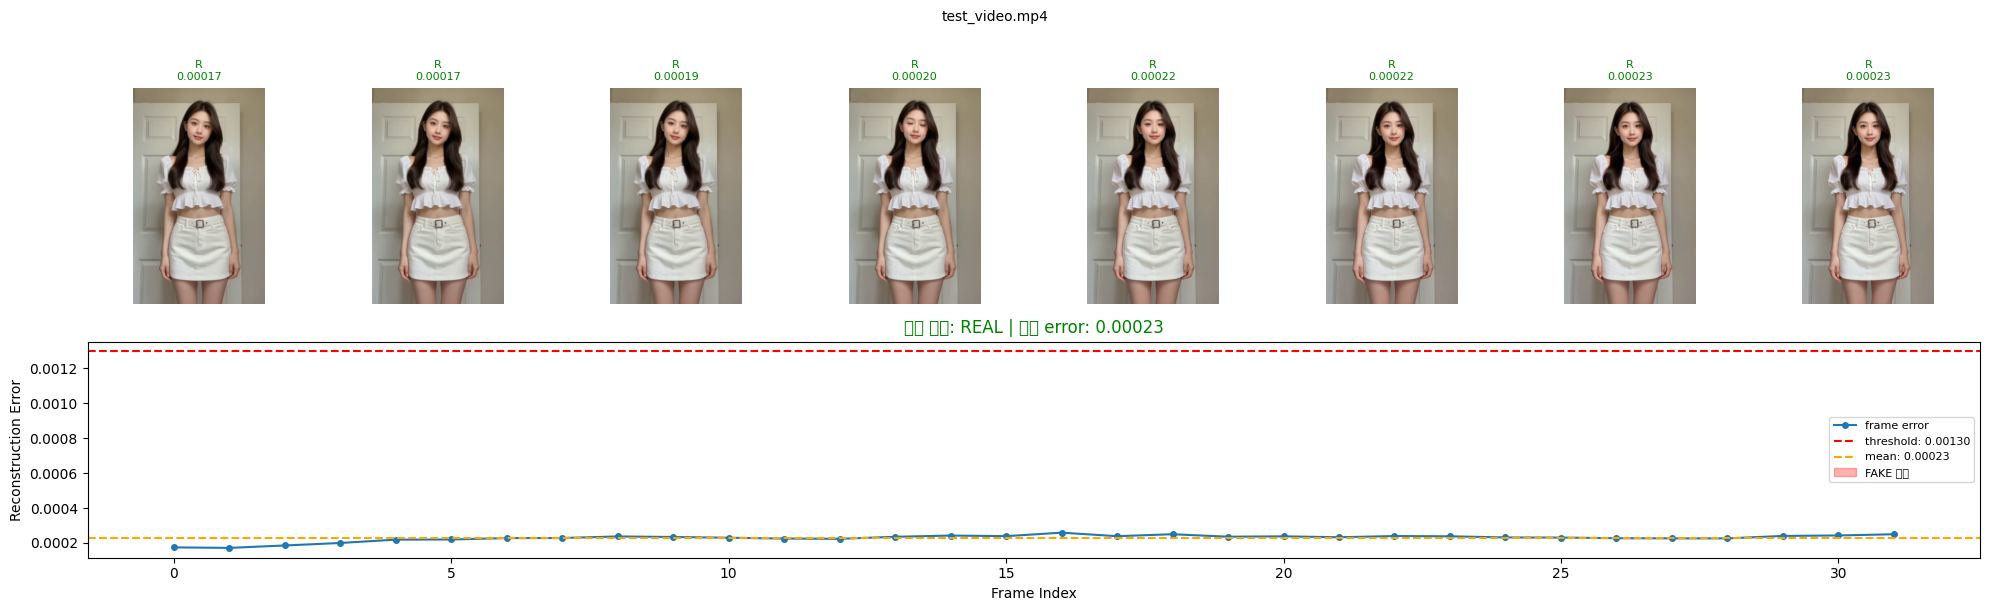

시각화 저장: C:\Users\user\Desktop\deepfake-detector\models\occ\inference_test_video.png


In [14]:
# ============================================================
# 셀 6 - 영상 테스트
# 테스트할 영상 경로를 넣고 실행하면
# 프레임별 error 분포와 최종 판별 결과를 보여줍니다.
# sample_frames: 몇 개 프레임을 샘플링할지 (기본 32장)
# ============================================================

video_path = r"C:\Users\user\Desktop\deepfake-detector\test_samples\video\fake\test_video.mp4"  # 경로 수정
result = predict_video(video_path, sample_frames=32)

In [21]:
# VidProM fake 영상 샘플 20개 테스트
import random

test_folder = Path(r"C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all")
video_files = list(test_folder.glob("*.mp4"))

random.seed(42)
sampled = random.sample(video_files, min(20, len(video_files)))

print(f"전체 영상: {len(video_files)}개 → 샘플: {len(sampled)}개\n")

results = []
for i, vp in enumerate(sampled):
    print(f"[{i+1}/20] {vp.name}")
    r = predict_video(vp, sample_frames=32, visualize=False)
    if r:
        results.append({"file": vp.name, **r})
    print("-" * 40)

fake_count = sum(1 for r in results if r["result"] == "FAKE")
real_count = sum(1 for r in results if r["result"] == "REAL")
print(f"\n===== 결과 요약 =====")
print(f"FAKE 판별: {fake_count}개 ({fake_count/len(results)*100:.1f}%)")
print(f"REAL 판별: {real_count}개 ({real_count/len(results)*100:.1f}%)")
print(f"\n파일별 결과:")
for r in results:
    print(f"  {r['result']} | error: {r['mean_error']:.6f} | {r['file']}")

전체 영상: 57663개 → 샘플: 20개

[1/20] pika-b9421276-26c8-553c-8788-1eaf86f4bc56.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-b9421276-26c8-553c-8788-1eaf86f4bc56.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 error:  0.000510
threshold:   0.001297
FAKE 판정 프레임 비율: 0.0%
최종 판별: REAL
----------------------------------------
[2/20] pika-1fdc4344-ce50-5900-9ff9-e09a68b53de7.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-1fdc4344-ce50-5900-9ff9-e09a68b53de7.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 error:  0.000889
threshold:   0.001297
FAKE 판정 프레임 비율: 0.0%
최종 판별: REAL
----------------------------------------
[3/20] pika-0753e089-a923-5bc6-82e2-c6e6143aa365.mp4

경로: C:\Users\user\Desktop\deepfake-detector\data\vidprom\pika_fake\pika_videos_all\pika-0753e089-a923-5bc6-82e2-c6e6143aa365.mp4
총 프레임: 72 | FPS: 24.0 | 길이: 3.0초
샘플 프레임: 32장
평균 error:  0.000491
threshold:   0.001297
FAKE 판정 프레임 비율: 0

In [ ]:
# ============================================================
# 셀 7 - 폴더 내 여러 영상 일괄 테스트
# 폴더 경로를 지정하면 안에 있는 mp4 전부 테스트하고
# 결과를 요약해서 출력합니다.
# fake 영상 가져왔을 때 탐지율 확인용으로 쓰세요.
# ============================================================

test_folder = Path(r"C:\Users\user\Desktop\테스트영상폴더")  # 경로 수정
video_files = list(test_folder.glob("*.mp4"))

print(f"테스트 영상 수: {len(video_files)}개\n")

results = []
for i, vp in enumerate(video_files):
    print(f"[{i+1}/{len(video_files)}] {vp.name}")
    r = predict_video(vp, sample_frames=32, visualize=False)
    if r:
        results.append({"file": vp.name, **r})
    print("-" * 40)

# 결과 요약
print("\n===== 최종 요약 =====")
fake_count = sum(1 for r in results if r["result"] == "FAKE")
real_count = sum(1 for r in results if r["result"] == "REAL")
print(f"총 영상: {len(results)}개")
print(f"FAKE 판별: {fake_count}개 ({fake_count/len(results)*100:.1f}%)")
print(f"REAL 판별: {real_count}개 ({real_count/len(results)*100:.1f}%)")
print(f"\n파일별 결과:")
for r in results:
    print(f"  {r['result']} | error: {r['mean_error']:.6f} | {r['file']}")

In [22]:
from pathlib import Path

BASE = Path(r"C:\Users\user\Desktop\deepfake-detector")

real_frames = list((BASE / "data" / "real_frames" / "documentary").glob("*.jpg")) + \
              list((BASE / "data" / "real_frames" / "vlog").glob("*.jpg"))

fake_frames = list((BASE / "data" / "vidprom" / "frames" / "fake").glob("*.jpg"))

print(f"real 프레임: {len(real_frames)}장")
print(f"fake 프레임: {len(fake_frames)}장")

real 프레임: 86067장
fake 프레임: 12521장
